<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
<a href="https://sebastianraschka.com">Sebastian Raschka</a> 所著《<a href="https://mng.bz/lZ5B">从零开始构建推理模型</a>》一书的补充代码<br>
<br>代码仓库：<a href="https://github.com/rasbt/reasoning-from-scratch">https://github.com/rasbt/reasoning-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="https://mng.bz/lZ5B"><img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# 第七章：改进强化学习的GRPO

本笔记本中正在使用的包：

In [1]:
from importlib.metadata import version

used_libraries = [
    "reasoning_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

reasoning_from_scratch version: 0.1.21
torch version: 2.7.1
tokenizers version: 0.22.2


<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F01_raschka.webp?1" width=600>

&nbsp;
## 7.1 改进 GRPO

- 注意：如果本章内容过于技术性且您对GRPO的额外细节不感兴趣，可以跳过；下一章内容不依赖本章。

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F02_raschka.webp?1" width=400>

&nbsp;
## 7.2 追踪GRPO性能指标

- 我们在上一章进行了一次简短的RLVR训练运行，并简要讨论了结果

- 例如，在上一部分中，我们看到了短时间运行的输出，其结构如下：

```
[Step 1/50] loss=-0.0000 reward_avg=0.000 avg_resp_len=5.5
[Step 2/50] loss=-0.0000 reward_avg=0.000 avg_resp_len=6.8
[Step 3/50] loss=0.3592 reward_avg=0.250 avg_resp_len=7.8
[Step 4/50] loss=2.7401 reward_avg=0.250 avg_resp_len=56.5
[Step 5/50] loss=3.3214 reward_avg=0.500 avg_resp_len=251.2
# ...
```

- 在本部分中，我们接着上一部分的内容，讨论运行 RLVR 时需要跟踪的一些指标。

&nbsp;
### 7.2.1 执行一次 GRPO 训练运行

- 第六章的代码试图在展示完整GRPO流程与保持简洁以提高可读性之间取得平衡
- 补充材料中包含一个脚本（[ch06/02_rlvr_grpo_scripts_intro/rlvr_grpo_original_no_kl.py](https://github.com/rasbt/reasoning-from-scratch/blob/main/ch06/02_rlvr_grpo_scripts_intro/rlvr_grpo_original_no_kl.py)），其中包含相同代码，但从代码终端运行可能更为便捷
- 本章中，为方便起见并避免过多代码重复导致笔记本和章节内容杂乱，我们将引用补充材料中的脚本
- 通过以下辅助函数，我们将在本章中从补充材料下载代码并保存到本地目录

In [2]:
from pathlib import Path
import requests

def download_from_github(rel_path, out=None):
    github_raw_base = (  # Base URL
        "https://raw.githubusercontent.com/rasbt/"
        "reasoning-from-scratch/refs/heads/main/"
    )

    rel_path = Path(rel_path)
    # Use URL file name as default output file name
    out = Path(out) if out is not None else Path(rel_path.name)

    # Skip download if file already exists locally
    if out.exists():
        size_kb = out.stat().st_size / 1e3
        print(f"{out}: {size_kb:.1f} KB (cached)")
        return out

    # Download file
    r = requests.get(github_raw_base + rel_path.as_posix())
    r.raise_for_status()

    out.write_bytes(r.content)
    size_kb = out.stat().st_size / 1e3
    print(f"{out}: {size_kb:.1f} KB")

- 下载GRPO脚本（基于第6章代码）：

In [3]:
download_from_github(
    "ch06/02_rlvr_grpo_scripts_intro/rlvr_grpo_original_no_kl.py"
)

rlvr_grpo_original_no_kl.py: 15.6 KB


- 如果下载的文件大小远小于上述显示的大小，可能是下载过程中出现了问题
- 请再次检查网址是否输入正确
- 此外，如果文件下载问题仍然存在，请参阅[故障排除指南](https://github.com/rasbt/reasoning-from-scratch/blob/main/troubleshooting.md)

- 如果您不想运行训练代码（这很合理，因为成本相对较高），补充材料中已提供以下运行的日志文件（后续将提供更多下载信息）：

```bash
uv run rlvr_grpo_original_no_kl.py \
    --steps 500  \
    --max_new_tokens 1024
```

- **提示：** 您可以在上述代码执行命令中添加 `--show_eta`，以显示针对您机器的脚本总运行时间估计值。

- 我建议在终端中运行脚本（使用上述命令），但也可以在 Jupyter notebook 的代码单元格中运行，只需在命令前添加感叹号 `!`，即：`!uv run rlvr_grpo_original_no_kl.py`
- 如果您不使用 `uv`，请将 `uv run` 替换为 `python`，即：`python rlvr_grpo_original_no_kl.py`

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F03_raschka.webp" width=600>

- 如前所述，您无需自行重现上述运行过程（这可能成本较高），而是可以通过以下方式下载日志文件：

In [4]:
# Log file in plain text

download_from_github(
    "ch07/02_logs/ch06_rlvr_grpo_original_no_kl_metrics.txt"
)

# Same log file in CSV format
download_from_github(
    "ch07/02_logs/ch06_rlvr_grpo_original_no_kl_metrics.csv"
)

ch06_rlvr_grpo_original_no_kl_metrics.txt: 43.7 KB
ch06_rlvr_grpo_original_no_kl_metrics.csv: 25.1 KB


&nbsp;
### 7.2.2 检查GRPO训练运行情况

- 本章中，我们使用以下实用函数来绘制日志文件中的结果

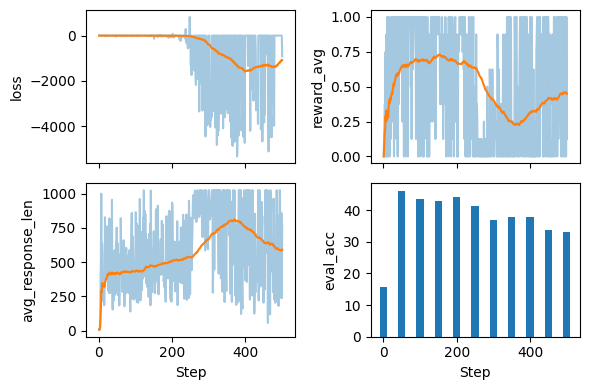

In [5]:
import csv
import matplotlib.pyplot as plt


def moving_average(values, window_fraction=0.25):
    # Smooth a noisy training signal to reveal longer-term trends during training
    window_size = max(1, int(window_fraction * len(values)))
    smoothed = []

    for i in range(len(values)):
        start_idx = max(0, i - window_size + 1)
        window_mean = sum(values[start_idx : i + 1]) / (i - start_idx + 1)
        smoothed.append(window_mean)

    return smoothed


def plot_grpo_metrics(csv_path, columns, save_as=None):
    data = {name: {"steps": [], "values": []} for name in columns}

    # Open and read CSV log file
    with Path(csv_path).open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if not row or not row.get("step"):
                continue

            # Use the training step as the shared x-axis across all metrics
            step = int(row["step"])

            for name in columns:
                value_str = row.get(name)
                if value_str:
                    data[name]["steps"].append(step)
                    data[name]["values"].append(float(value_str))

    # Create a fixed grid so loss, rewards, response length, etc. can be shown side by side
    fig, axes = plt.subplots(2, 2, sharex=True, figsize=(6, 4))
    axes = axes.ravel()

    for i, name in enumerate(columns):
        steps = data[name]["steps"]
        values = data[name]["values"]

        # Skip metrics that are not present
        if not values:
            fig.delaxes(axes[i])
            continue

        # Evaluation accuracy as barplot because we don't have data for each step
        if name == "eval_acc":
            axes[i].bar(steps, values, width=20)
        else:
            axes[i].plot(steps, values, alpha=0.4)
            axes[i].plot(steps, moving_average(values))

        axes[i].set_ylabel(name)

    for j in (2, 3):
        if axes[j] in fig.axes:
            axes[j].set_xlabel("Step")

    plt.tight_layout()
    if save_as is not None:
        plt.savefig(save_as)
    plt.show()


# Plot the GRPO training run
plot_grpo_metrics(
    "ch06_rlvr_grpo_original_no_kl_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    # save_as="4.pdf"
)

- 以下是一些总体观察和思考：
  - 平均响应长度初期应上升（理想情况下准确率也同步提升）；整体来看表现良好，尽管在接近第400步时出现了一些下降
  - 与预训练阶段相比，损失指标的参考价值有限；它应保持相对平稳，但存在一定波动是可接受的（不过末期出现的尖峰略显令人担忧）
- 平均奖励值应呈上升趋势；严格来说，1.00的平均奖励意味着所有回答都正确，这非常理想，但这也意味着训练信号已完全消失，此时应停止训练
- 目标/外部任务表现（此处指MATH-500准确率）应持续提升；初期确实如此，但随后出现了下降

- 总结：我们获得了快速的早期收益，随后收益递减
  - 一个原因是算法稳定性不足
  - （另一种可能的解释是问题难度增加，但那样我们就不会看到评估准确率的下降）

- 请注意，我们在此专注于简化追踪GRPO运行；下一节将补充更多内容
- 顺便一提，评估准确率（此处指：MATH-500准确率）默认不被追踪
- 可通过添加 `--eval_on_checkpoint 500` 在训练期间基于500个MATH-500测试样本计算，但这会减慢训练速度
- 或者，可使用 `evaluate_math500.py` 脚本（包含第3章代码）在训练后计算

In [6]:
download_from_github(
    "ch03/02_math500-verifier-scripts/evaluate_math500.py"
)

evaluate_math500.py: 3.5 KB


- 评估随后可在给定的检查点上按如下方式运行：

```bash
uv run evaluate_math500.py \
  --dataset_size 500 \
  --checkpoint_path \
    "checkpoints/rlvr_grpo_original_no_kl/\
qwen3-0.6B-rlvr-grpo-step00050.pth"
```

- 我已经将这些评估运行的结果，每50步一次，添加到了我们之前分析的日志文件中。

&nbsp;
## 7.3 追踪更高级的GRPO性能指标

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F05_raschka.webp" width=400>

- 在上一节中，我们探讨了用于跟踪GRPO运行的基本性能指标
- 还有其他几个有用的指标可供追踪
- 两个例子包括
  - 我们在 `compute_grpo_loss` 函数中已经计算的优势（第6章）
  - 计算序列的熵值

&nbsp;
### 7.3.1 优势追踪

- 作为GRPO算法的一部分，我们计算了前文（第6章）讨论的所谓优势
- 这些优势同样有助于分析训练动态

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F06_raschka.webp" width=400>

- 具体而言，我们基于优势值计算了两个新的汇总统计量：平均值（即样本 `mean`）和标准差（`std`）

In [7]:
import torch

def compute_advantage_stats(rewards_list):
    # This is what we already compute in GRPO:
    rewards = torch.tensor(rewards_list)
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

    # These are the new statistics we add:
    adv_avg = advantages.mean().item()
    adv_std = advantages.std().item()

    return advantages, adv_avg, adv_std

- 以下是一个使用四个奖励值的小样本示例（类似于上图所示）

In [8]:
adv, adv_avg, adv_std = compute_advantage_stats([1., 1., 0., 0.])

print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")

Advantages: tensor([ 0.8659,  0.8659, -0.8659, -0.8659])
Advantage mean = 0.0000, std = 0.9998


- 均值：
  - 需要注意的是，由于我们计算优势值的方式，均值将始终为0；在GRPO中，这仅作为代码按预期运行的合理性检查

- 标准差：
  - 此处标准差包含更多信息
  - std ≈ 1 表示梯度信号尺度良好，有利于稳定更新
  - std ≪ 1 表示信号衰减（常发生在奖励坍缩时）
  - std ≫ 1 表示更新过于尖锐，可能破坏训练稳定性

- 极端情况是指所有奖励都相似的情况；此时标准差为0，我们可以将其用作检测训练信号缺失的指标

In [9]:
adv, adv_avg, adv_std = compute_advantage_stats([0., 0., 0., 0.])
print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")

Advantages: tensor([0., 0., 0., 0.])
Advantage mean = 0.0000, std = 0.0000


In [10]:
adv, adv_avg, adv_std = compute_advantage_stats([1., 1., 1., 1.])
print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")

Advantages: tensor([0., 0., 0., 0.])
Advantage mean = 0.0000, std = 0.0000


- 实践中，最好将优势统计与奖励平均值结合来看，因为如前所述，奖励平均值为1实际上是件好事；虽然我们不再有训练信号，但模型已能正确回答所有问题
- 此时，我们应停止训练或选择更难的样本

&nbsp;
### 7.3.2 熵跟踪

- 熵值衡量大语言模型生成下一个token时的不确定性程度
  - 高熵：模型将概率质量分散到多个token上（有利于探索）
  - 低熵：模型几乎将所有概率质量集中在一个token上（行为更具确定性，可能预示着潜在的模式坍塌）

- 在计算熵之前，让我们先回顾一下第5章中是如何计算对数概率值（logprobs）的：

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F07_raschka.webp" width=600>

- 我们不使用通过提示基础模型生成的真实对数几率，而是采用假设词汇表大小为7的示例对数几率（否则，若使用原始15.1万词汇表，上图中的内容会显得过于杂乱）

In [11]:
# Toy logits
logits = torch.tensor([
    0.6667, -2.0000,  1.3333, -0.0000, -0.6667,  2.0000, -1.3333
])

- 以下代码实现了上图中的计算：

In [12]:
logprobs = torch.log_softmax(logits, dim=-1)
print("All token logprobs:", logprobs)

# Index of the selected token
selected_token = torch.argmax(logprobs)

selected = logprobs[selected_token]
print("Selected token ID:", selected_token)
print("Selected token logprob:", selected)

All token logprobs: tensor([-2.0442, -4.7109, -1.3776, -2.7109, -3.3776, -0.7109, -4.0442])
Selected token ID: tensor(5)
Selected token logprob: tensor(-0.7109)


- 熵是一个相关概念；我们通过将概率值与对数概率值相乘，然后将这些乘积相加来计算它，如下图所示
- 原则上，也可以追踪更简单的量，如概率之和或对数概率之和，但熵是概率分布中不确定性的一种公认且可解释的度量

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F08_raschka.webp" width=400>

- 顺便一提，根据经验法则：
  - 极低熵值（≈ 0–0.5）意味着某个 token 主导了概率分布，此时模型置信度极高，行为近乎确定性
  - 中等熵值（≈ 1–2）意味着概率质量由更多 token 共享，这在稳定训练阶段较为典型
  - 高熵值（≫ 2，趋近 log(词汇量大小)；此处：log(7) = 1.9459）意味着概率质量分散在众多 token 上，模型不确定性极高，行为接近随机

- 我们可以如下计算熵：

In [13]:
# Probabilities from logits
probs = torch.softmax(logits, dim=-1)
logprobs = torch.log_softmax(logits, dim=-1)

# Entropy from probabilities
entropy = torch.sum(-(probs * logprobs))

print("Probs:", probs)
print("Entropy:", entropy)

Probs: tensor([0.1295, 0.0090, 0.2522, 0.0665, 0.0341, 0.4912, 0.0175])
Entropy: tensor(1.3700)


- 或者，如果我们只有对数值概率，可以通过 `torch.exp` 将对数值概率转换回概率值
- 您可以看到下面的值与上面的 "probs" 值相匹配：

In [14]:
print("Probs:", torch.exp(logprobs))

Probs: tensor([0.1295, 0.0090, 0.2522, 0.0665, 0.0341, 0.4912, 0.0175])


- 运用上述概念，我们可以将前一章中的 `sequence_logprob` 函数升级为 `sequence_logprob_and_entropy` 函数，该函数同时返回对数概率和熵值：

In [15]:
def sequence_logprob_and_entropy(model, token_ids, prompt_len):
    # Old: Code is identical to chapter 5
    logits = model(token_ids.unsqueeze(0)).squeeze(0).float()
    logprobs = torch.log_softmax(logits, dim=-1)

    targets = token_ids[1:]
    selected = logprobs[:-1].gather(1, targets.unsqueeze(-1)).squeeze(-1)

    # Log-prob of the generated answer tokens (sum over answer steps)
    selected_answer_logprobs = selected[prompt_len - 1:]
    logp_all_steps = torch.sum(selected_answer_logprobs)

    # New: Calculate entropy
    all_answer_logprobs = logprobs[:-1][prompt_len - 1:]
    if all_answer_logprobs.numel() == 0:  # Safeguard if the model immediately returns EOS token
        entropy_all_steps = logp_all_steps.new_tensor(0.0)
    else:
        all_answer_probs = torch.exp(all_answer_logprobs)  # convert logprob to prob
        plogp = all_answer_probs * all_answer_logprobs     # elementwise p * log p
        step_entropy = -torch.sum(plogp, dim=-1)           # sum over vocab -> entropy per step
        entropy_all_steps = torch.mean(step_entropy)       # average over answer steps

    return logp_all_steps, entropy_all_steps

- 我们可以在 `compute_grpo_loss` 函数内部使用此函数来同时计算熵值，以便在训练过程中进行跟踪
- 需要注意的是，前一张图展示了 LLM 推演过程中单个 token 的熵计算（`step_entropy`）；而 `sequence_logprob_and_entropy` 函数计算的是所有答案 token 的平均熵值：`entropy_all_steps = torch.mean(step_entropy)`
- 例如，若考虑答案 `"this is the LLM response"`，则步骤熵指的是单个 token（如 `"this"`）的熵值，而所有答案步骤的平均熵则是对所有答案 token `"this is the LLM response"` 计算的平均熵值

&nbsp;
### 7.3.3 绘制额外的 GRPO 指标

- 让我们通过实际运行来观察，并分析训练过程中的优势统计和熵值变化
- 为此，我们可以在 `compute_grpo_loss` 中替换 `sequence_logprob_and_entropy`，然后在内部调用该函数的 `train_rlvr_grpo` 中打印并追踪熵值
- 为避免冗长的代码重复，完整修改后的代码已提供在补充材料中，可通过以下方式下载：

In [16]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_3_plus_tracking.py"
)

7_3_plus_tracking.py: 16.9 KB


- 该代码的运行方式与我们之前讨论的训练脚本类似：

```bash
uv run 7_3_plus_tracking.py \
    --steps 500  \
    --max_new_tokens 1024
```

- 由于训练耗时较长，生成的CSV日志文件可按如下方式下载：

In [17]:
download_from_github(
    "ch07/02_logs/7_3_plus_tracking_metrics.csv"
)

7_3_plus_tracking_metrics.csv: 39.0 KB


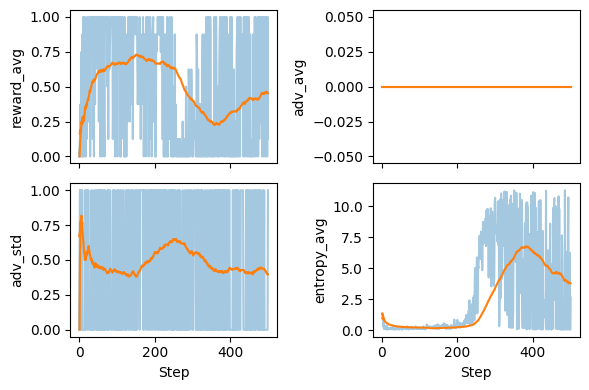

In [18]:
plot_grpo_metrics(
    "7_3_plus_tracking_metrics.csv",
    columns=["reward_avg", "adv_avg", "adv_std", "entropy_avg"],
    # save_as="9.pdf"
)

- 平均优势值始终为零，这正是GRPO式归一化所预期的结果
  - 优势值是相对于组均值计算的，因此从构造上讲，它们的总和应为零
  - 该指标在GRPO中主要作为完整性检查，若其偏离零值，则可能表明存在缺陷或其他归一化偏差问题
- 优势标准差是更具信息量的信号
  - 早期阶段观察到相对较高的方差，表明模型生成了多样化的推演结果
  - 随后优势标准差逐渐下降并趋于稳定，意味着推演结果的质量差异逐渐缩小
  - 关键在于，非零（且稳定）的优势标准差表明仍存在可用的学习信号

- 接下来，我们来看熵值变化
  - 训练初期，熵值相对平坦且较低（这表明大语言模型具有较强确定性）
  - 实际操作中，提高采样温度会增加推理过程中的输出多样性，但这并不会改变底层大语言模型的熵值
  - 训练后期（约200步之后），熵值显著上升，这意味着下一个词元的分布变得更宽泛，模型随机性增强
  - 极低熵值可能是模型崩溃的征兆，表现为模型反复生成相同或高度相似的输出
  - 但在本次运行中，结合熵值、奖励均值和非零优势标准差来看，这更表明模型处于健康探索状态而非崩溃

简而言之，单独指标能反映不同信息，但结合上下文进行综合分析更具价值。

&nbsp;
## 7.4 使用裁剪策略比率稳定序列级GRPO

- 目前，我们主要专注于分析GRPO训练结果
- 接下来，我们开始对GRPO算法进行改进
- 我们目前使用的GRPO算法是简化版本，本节重点介绍在GRPO损失函数中采用截断策略比率

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F10_raschka.webp" width=400>

&nbsp;
### 7.4.1 计算裁剪后的策略比率

- 裁剪策略比率衡量当前策略（正在训练的LLM）与同一策略早期版本的差异程度
- 具体而言，它比较更新步骤前计算的序列对数概率与更新后计算的序列对数概率
- 在下图所示的GRPO流程中，这对应于比较步骤4（使用旧参数计算）的对数概率与步骤6后更新模型产生的对数概率

<img src="https://sebastianraschka.com/images/从零开始推理的图像/ch07/CH07_F11_raschka.webp?1" width=400>

- 回顾一下，在上一章中，我们按如下方式计算了策略梯度损失：

In [19]:
# Compute rollouts
# ...

# Compute rewards
rewards = torch.tensor([1., 1., 0., 0.])

# Compute sequence logprobs
logprobs = torch.tensor([-7.9243, -20.1546, -16.6130, -23.3677])

advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

pg_loss = -(advantages.detach() * logprobs).mean()
print("Policy gradient loss:", pg_loss)

Policy gradient loss: tensor(-2.5764)


- 裁剪比率是通过先前策略的对数概率（`old_logps`）与当前对数概率（`new_logps`）计算得出的
- 其推导过程超出本文范围，但感兴趣的读者可在[近端策略优化算法](https://arxiv.org/pdf/1707.06347)论文中获取更多信息
- 为便于说明，我们使用上述示例中的对数概率作为`old_logps`，假设进行了模型更新，并用更新后的模型计算`new_logps`（此处新旧策略使用相同提示词以确保公平比较）

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F12_raschka.webp?2" width=600>

In [20]:
new_logps = logprobs

# The values of the new_logps
# are shown side by side in the comments
old_logps = torch.tensor([
    -10.9243,   # -7.9243
    -20.3546,   # -20.1546
    -14.6130,   # -16.6130
    -23.3677,   # -23.3677
])

log_ratio = new_logps - old_logps
ratio = torch.exp(log_ratio)
clip_eps = 10.0
clipped_ratio = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps)

print("Ratio:        ", ratio)
print("Clipped ratio:", clipped_ratio)

Ratio:         tensor([20.0855,  1.2214,  0.1353,  1.0000])
Clipped ratio: tensor([11.0000,  1.2214,  0.1353,  1.0000])


- `ratio` 告诉我们新旧对数概率之间的差异程度；如果两者相同，我们会看到 1.0
- `clipped_ratio` 强制限制与旧策略的最大偏差，以确保更新保持相对保守并提高训练稳定性
- 特别地，通常将其限制在 1 +/- `clip_eps` 范围内；在 DeepSeek-R1 训练中，clip_eps 设置为 10，这意味着非常弱的裁剪（然而，在其他强化学习训练流程中，将 `clip_eps` 设置为更小的值（如 0.1）也很常见）

- 接下来，我们将 `ratio` 和 `clipped_ratio` 应用于损失计算
- 之前，我们直接将 advantages 和 logprobs 相乘
- 现在，我们通过策略比率对 advantages 进行缩放，并使用截断目标函数来限制每次 rollout 对更新的影响程度

In [21]:
# Treat advantages as fixed learning signals (no backprop through rewards)
adv = advantages.detach()

unclipped = ratio * adv
clipped = clipped_ratio * adv

# PPO-style clipping
obj = torch.minimum(unclipped, clipped)

    
clipped_pg_loss = -torch.mean(obj)
policy_ratio = torch.mean(ratio)

print("Clipped policy gradient loss:", clipped_pg_loss)
print("Policy ratio:", policy_ratio)

Clipped policy gradient loss: tensor(-2.3998)
Policy ratio: tensor(5.6106)


- 本例中的高策略比率意味着更新后的策略（模型）为采样到的标记分配了比先前策略高得多的概率
- 请注意，裁剪后的策略梯度损失（-2.3998）现在略低于我们之前计算的常规策略梯度损失（-2.5764），这意味着模型权重的更新幅度比之前稍小
- 这种裁剪可以防止过于激进的更新，从而避免训练过程不稳定

- 作为参考，在GRPO中，部分方法使用token级概率，部分使用序列级概率。以下是常见变体的概述：

| 论文 | 类型 | 记法 |
|---|---|---|
| [DeepSeekMath GRPO](https://arxiv.org/abs/2402.03300)，2024 | Token级 | `r_{i,t}(theta) = pi_theta(o_{i,t} \| q, o_{i,<t}) / pi_theta_old(o_{i,t} \| q, o_{i,<t})` |
| [DeepSeek-R1 GRPO](https://arxiv.org/abs/2501.12948)，2025 | 序列级 | `r_i(theta) = pi_theta(o_i \| q) / pi_theta_old(o_i \| q)` |
| [DAPO](https://arxiv.org/abs/2503.14476)，2025 | Token级 | `r_{i,t}(theta) = pi_theta(o_{i,t} \| q, o_{i,<t}) / pi_theta_old(o_{i,t} \| q, o_{i,<t})` |
| [GSPO](https://arxiv.org/abs/2507.18071)，2025 | 序列级 | `s_i(theta) = (pi_theta(y_i \| x) / pi_theta_old(y_i \| x))^(1 / \|y_i\|)` |

&nbsp;
### 7.4.2 使用截断策略比率进行训练

- 包含更新后GRPO训练的脚本现已实现裁剪策略比率计算，可从补充材料中下载：

In [22]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_4_plus_clip_ratio.py"
)

7_4_plus_clip_ratio.py: 17.2 KB (cached)


PosixPath('7_4_plus_clip_ratio.py')

- 与之前类似，我们可以按如下方式运行：

```bash
uv run 7_4_plus_clip_ratio.py \
    --steps 500  \
    --max_new_tokens 1024
```

- DeepSeek-R1 生成大规模滚动样本池（8192个），将其分为16个小批量，并对这些小批量执行一轮内层训练
- 具体方法如下：
  1. 将当前模型复制作为参考策略
  2. 使用参考策略采样大型滚动样本池
  3. 将这些固定的滚动样本划分为小批量
  4. 针对每个小批量：
      - 计算参考模型下的 `old_logps`
      - 计算当前模型下的 `new_logps`（该模型会在每次小批量更新后变化）
      - 更新当前模型
  5. 更新参考模型

- 受限于资源限制，我们无法生成那么多的轨迹和小批量数据，必须使用变通方案
1. 我们将当前模型复制一份作为参考策略
2. 使用参考策略采样8条轨迹
3. 接着我们计算：
  - 参考模型下的 `old_logps`
  - 当前模型下的 `new_logps`
  - 更新当前模型
4. 使用不同的轨迹重复步骤2和3，而非使用小批量数据
5. 更新参考模型

- 简而言之，DeepSeek-R1 一次性生成庞大的 rollout 池，随后以小批量的方式遍历处理
- 在我们的代码中，我们会多次生成小批量的 rollout 数据

- 本次运行的日志文件可按如下所示下载并可视化：

In [23]:
download_from_github(
    "ch07/02_logs/7_4_plus_clip_ratio_metrics.csv",
)

7_4_plus_clip_ratio_metrics.csv: 42.7 KB (cached)


PosixPath('7_4_plus_clip_ratio_metrics.csv')

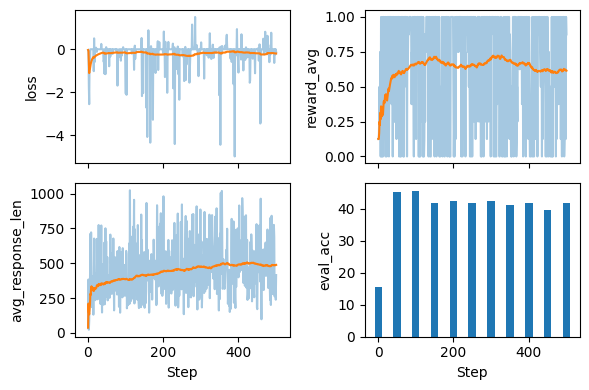

In [24]:
plot_grpo_metrics(
    "7_4_plus_clip_ratio_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    save_as="13_1.pdf"
)

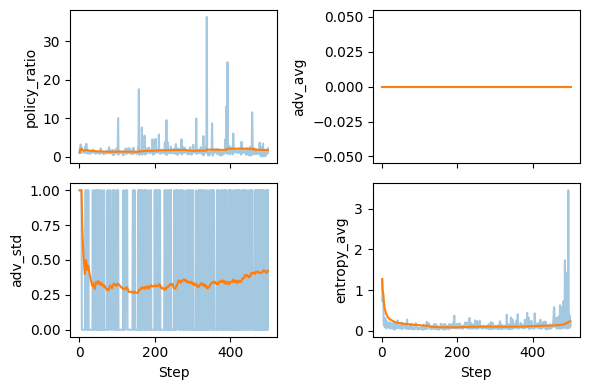

In [25]:
plot_grpo_metrics(
    "7_4_plus_clip_ratio_metrics.csv",
    columns=["policy_ratio", "adv_avg", "adv_std", "entropy_avg"],
    save_as="13_2.pdf"
)

根据上述图表，我们可以看到训练现在更加稳定，因为在400步左右不再出现下降。

&nbsp;
## 7.5 使用KL项控制模型变化幅度

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F14_raschka.webp?2" width=400>

- 在上一章中，我们跳过了 GRPO 算法的 KL 损失项，因为那章内容已经很长了  
- 熟悉强化学习（RL）算法的读者可能看出，我们本质上实现了带分组归一化优势的 [REINFORCE](https://en.wikipedia.org/wiki/Policy_gradient_method#REINFORCE)  
- 为了完善 GRPO 算法，我们现在加入 KL 损失项  
- KL 是 Kullback-Leibler 散度的缩写，用于衡量当前策略（我们正在训练的大语言模型）与参考策略（训练开始时的原始大语言模型）之间的偏差  
- 它起到正则化作用，防止策略更新过于剧烈，有助于模型保持与原始行为的接近程度，避免出现不稳定的大规模更新  
- 这与我们之前实现的策略裁剪比率并非无关：之前我们只关注更新步长的大小，现在则明确最小化长期漂移

&nbsp;
### 7.5.1 实现 KL 损失项

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F15_raschka.webp?2" width=400>

- 对于每次推演，我们使用完全相同的生成令牌，分别计算当前策略（模型）和固定参考模型下的对数概率，如图右侧所示。
- 随后通过累加对应对数概率的差异来计算KL散度，该指标量化了当前策略相对于参考模型的偏移程度。
- 该KL项被加入策略梯度损失函数中，因此在训练过程中，那些提升奖励但同时大幅增加与参考模型差异（发散度）的权重更新会受到惩罚。
- 此处的参考模型是训练开始前的原始模型（在DeepSeek-R1中，该参考模型每400步会更新为最新模型）。

- 为避免代码重复，下方代码未展示完整的 `compute_grpo_loss_with_kl` 修改版本，仅聚焦于我们需对 `compute_grpo_loss` 函数进行的必要改动
- 新增部分包括通过 `"# New"` 标记的内容，以及 `if kl_coeff` 条件分支下的内容

In [26]:
import copy

# kl_coeff = 0.0 deactivates the KL term and the code is similar to before
kl_coeff = 0.0  

# Make copy of the original model and disable gradients so it isn't updated
if kl_coeff:
    ref_model = copy.deepcopy(model).to(device)  # noqa: F821
    ref_model.eval()
    for p in ref_model.parameters():
        p.requires_grad = False
else:
    ref_model = None


def compute_grpo_loss_with_kl(
    model,
    ref_model,  # New
    # ...
    kl_coeff=0.02,  # New
):
    roll_logps, roll_ref_logps, roll_rewards, samples = [], [], [], []  # noqa: F841
    # ...

    for _ in range(num_rollouts):  # noqa: F821
        token_ids, prompt_len, text = sample_response(  # noqa: F821
        # ...
        )

        # Compute logprobs with reference model
        if kl_coeff:
            with torch.no_grad():
                ref_logp = sequence_logprob(  # noqa: F821
                    ref_model, token_ids, prompt_len
                )
        else:
            ref_logp = None

        reward = reward_rlvr(text, example["answer"])  # noqa: F821

        roll_rewards.append(reward)
        roll_logps.append(logp)  # noqa: F821
        if kl_coeff:
            roll_ref_logps.append(ref_logp)
        
        # ...

    rewards = torch.tensor(roll_rewards, device=device)  # noqa: F841
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

    logps = torch.stack(roll_logps)
    if kl_coeff:
        ref_logps = torch.stack(roll_ref_logps).detach()

    pg_loss = -(advantages.detach() * logps).mean()

    # Compute KL loss term
    if kl_coeff:
        kl_loss = kl_coeff * torch.mean(logps - ref_logps)
    else:
        kl_loss = torch.tensor(0.0, device=logps.device)

    # Add KL loss term to policy gradient loss
    loss = pg_loss + kl_loss  # noqa: F841

- 注意，添加 KL 损失项会增加额外的资源需求，因为我们现在需要保留原始模型的额外副本
- `kl_coeff` 值越大，散度惩罚就越强

&nbsp;
### 7.5.2 使用KL损失项进行训练

我们可以从补充材料中下载完整脚本，如下所示。

In [27]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_5_plus_kl.py"
)

7_5_plus_kl.py: 18.8 KB (cached)


PosixPath('7_5_plus_kl.py')

- 与之前类似，我们可以按如下方式运行：

```bash
uv run 7_5_plus_kl.py \
    --steps 500  \
    --max_new_tokens 1024
```

- 与之前类似，我们可以下载以下日志文件进行分析，因为运行实验可能资源密集且成本高昂：

In [28]:
download_from_github(
    "ch07/02_logs/"
    "7_5_plus_kl_metrics.csv"
)

7_5_plus_kl_metrics.csv: 48.8 KB (cached)


PosixPath('7_5_plus_kl_metrics.csv')

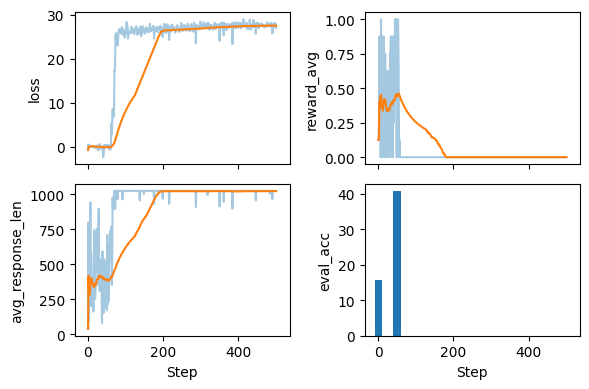

In [29]:
plot_grpo_metrics(
    "7_5_plus_kl_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    # save_as="16.pdf"
)

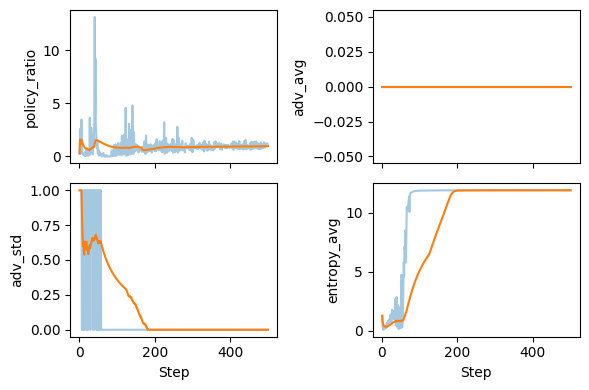

In [30]:
plot_grpo_metrics(
    "7_5_plus_kl_metrics.csv",
    columns=["policy_ratio", "adv_avg", "adv_std", "entropy_avg"],
)

- 我们可以看到训练在50步后不久就崩溃了，评估准确率也趋向于0
- 对生成的模型响应进行人工检查后发现，模型开始输出无意义的文本和随机token，例如`"framework.raises Self profess(import"`
- 这可能有多种原因：
1. KL项是基于求和的对数概率计算的
   - `kl_loss = kl_coeff * mean(new_logps - ref_logps)`，其中`new_logps`和`ref_logps`是对答案token求和的结果
   - 因此，较长序列会导致KL项的幅度增大，这可能会激励生成非常长的输出（从不断增长的响应长度可以看出），并破坏训练的稳定性
2. 一旦奖励在200步左右崩溃，KL就成为唯一的梯度来源
   - 当所有奖励都为零时，优势值变为0，因此策略梯度损失没有梯度
   - 然而，KL项仍然存在，随后主导更新并可能将模型推向更高熵/接近均匀的分布，这解释了生成答案中的随机性（以及0.0%的评估准确率）

- 尽管KL项是GRPO的标准组成部分（这正是我们在此引入它的原因），但一些研究者发现去除该模型可能获得更佳的训练效果，例如：
  - [Dr. GRPO](https://arxiv.org/abs/2503.20783)
  - [Olmo 3](https://arxiv.org/abs/2512.13961)
  - [DeepSeek V3.2](https://arxiv.org/abs/2512.02556)

或者，我们可以采用不同的方式来稳定训练过程

1. 使用逐令牌对数概率对长度进行归一化处理，并计算KL散度
   - 为使用逐令牌对数概率，我们需要在策略比率和KL项计算前除以生成长度
   - 这能消除人为增加序列长度的动机

2. 降低 `kl_coeff` 参数值（例如降至0.001，但我发现此处该方法亦无效）
       
3. 使用加权KL项（重要性采样）
   - 原始公式：`kl_loss = kl_coeff * torch.mean(logps - ref_logps)`
   - 优化公式：`kl_loss = kl_coeff * torch.mean(torch.exp(new_logps - old_logps) * (new_logps - ref_logps))`

4. 添加微小格式奖励以防止优势值归零；我们将在下一章节详细讨论格式奖励

- 然而，如前所述，常规建议是在数学数据训练时避免使用KL项（Dr. GRPO、Olmo 3及DeepSeek V3.2均采用此方案）
  - 这同时简化了代码复杂度并降低资源需求

&nbsp;
## 7.6 添加显式格式奖励

- 到目前为止，我们只使用单一的正确性奖励；在本节中，我们将新增第二个格式奖励，这与 DeepSeek-R1 的做法类似

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F17_raschka.webp?1" width=400>

&nbsp;
### 7.6.1 使用 `` 标记

`作为代码标记不能翻译，DeepSeek-R1和Qwen3这类专有名词保留英文。技术术语如tokenizer要根据上下文决定，这里"tokenizer"在中文技术社区通常不翻译。

格式方面要完全保留原列表结构，标点符号改为中文全角。第一句的"so-called"可以译为"所谓的"保持语气，第二句的转折关系用"虽然...但..."更符合中文表达习惯。

想到几个关键点：代码块标记要原样保留，专有名词不翻译，术语一致性检查，列表项符号统一转换为中文格式。整段逻辑比较清晰，按顺序处理即可。</think>- 一些推理模型（如 DeepSeek-R1 和 Qwen3）使用所谓的 `` `</think>` 标记
- 这并非必需，但有助于引导模型将中间推理过程与最终答案分离，并保持输出结构的一致性
- 让我们加载之前使用的基础模型的 tokenizer：

In [31]:
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import load_model_and_tokenizer

device = get_device()
model, tokenizer_base = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


- 我们可以看到，它将 `` 标记分解成了多个子词标记，这表明 `` 标记不在词表中：

In [32]:
print(tokenizer_base.encode("<think>"))

[13708, 766, 29]


In [33]:
for i in [13708, 766, 29]:
    print(tokenizer_base.decode([i]))

<th
ink
>


- 分词器（tokenizer）有一些空占位符插槽，因此我们可以按如下方式将 `` 这个 token 添加到词汇表中：

In [34]:
tokenizer_base._tok.add_special_tokens(
    ["<tool_response>", "</tool_response>", "<think>", "</think>"]
)

4

In [35]:
print(tokenizer_base.encode("<think>"))

[151667]


In [36]:
print(tokenizer_base.encode("</think>"))

[151668]


"` should remain untranslated since they're inline code. "Qwen3" and "tokenizer" are technical terms that should stay in English as per rule 3. 

The phrase "reasoning variant" might be tricky - in this context, "reasoning" likely refers to the model's thinking capability, so "推理变体" seems appropriate. The rest is straightforward translation while preserving markdown formatting.

The sentence structure is simple, just need to ensure the Chinese flows naturally while keeping all technical terms intact. The phrase "which we will discuss shortly" can be smoothly translated as "稍后我们将讨论" at the end.</think>- 我们添加了 `""` 和 `"</think>"` 标记，以便与 Qwen3 推理变体的 tokenizer 保持一致，稍后我们将讨论该变体。

- 这些词元也会被模型支持，该模型支持词元ID范围从0到151935，因为其词汇表大小为151936

In [37]:
print("Vocabulary size:", model.tok_emb.weight.shape[0])

Vocabulary size: 151936


- 或者，推理模型变体的分词器已原生支持这些 `` 令牌

- 类似于我们在第2章中所做的，我们可以单独加载 tokenizer：

In [38]:
from reasoning_from_scratch.qwen3 import Qwen3Tokenizer
from reasoning_from_scratch.qwen3 import download_qwen3_small

download_qwen3_small(
    kind="reasoning", tokenizer_only=True, out_dir="qwen3"
)

tokenizer_path = Path("qwen3") / "tokenizer-reasoning.json"
tokenizer = Qwen3Tokenizer(tokenizer_file_path=tokenizer_path)

✓ qwen3/tokenizer-reasoning.json already up-to-date


In [39]:
print(tokenizer.encode("<think>"))

[151667]


In [40]:
print(tokenizer.encode("</think>"))

[151668]


`) and keeping the logical structure of the reward function explanation intact. 

The Chinese translation should use natural technical terminology like "奖励函数" for reward function and maintain the precise conditional logic (1.0/0.0 returns). I'll ensure the code tags remain untranslated as per standard practice in technical translations. 

The sentence structure needs to be adapted to Chinese word order while keeping the technical meaning identical. The colon after "输出" helps maintain the logical connection in Chinese.</think>- 然后我们可以设计一个奖励函数，用于检测大语言模型是否使用了 `` `</think>` 标签
- 若输出中同时存在 `` 与 `</think>` 且顺序正确，该函数返回 1.0；否则返回 0.0

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F18_raschka.webp?1" width=600>

In [41]:
def reward_format(
    token_ids,
    prompt_len,
    start_think_id=151667,
    end_think_id=151668,
):
    try:
        gen = token_ids[prompt_len:].tolist()
        return float(
            gen.index(start_think_id) < gen.index(end_think_id)
        )
    except ValueError:
        return 0.0

In [42]:
prompt = "Calculate ..."
rollout = "Let's ... <think> ... </think> ..."
token_ids = tokenizer.encode(prompt + rollout)

reward_format(
    token_ids=torch.tensor(token_ids),
    prompt_len=len(tokenizer.encode(prompt))
)

1.0

- 然后我们可以将格式奖励作为附加奖励信号来训练模型
- 例如，我们可以将 `compute_grpo_loss` 函数修改为 `compute_grpo_loss_plus_format_reward` 函数如下：

In [43]:
def compute_grpo_loss_plus_format_reward(
    # ...
    format_reward_weight=1.0,  # NEW
):
    # ...

        logp = sequence_logprob(model, token_ids, prompt_len)  # noqa: F821, F841
        rlvr_reward = reward_rlvr(text, example["answer"])  # noqa: F821
        format_reward = reward_format(token_ids, prompt_len)         # NEW  # noqa: F821
        reward = rlvr_reward + format_reward_weight * format_reward  # NEW  # noqa: F841

    # ...

- 此外，我们需要修改 `render_prompt` 以引导模型生成这些 `` 标记：

In [44]:
def render_prompt_with_think_tokens(prompt):
    template = (
        "You are a helpful math assistant.\n"
        "When solving the problem, first write your reasoning inside <think> and </think> tags.\n"
        "Then write the final result on a new line in the exact format:\n"
        "\\boxed{ANSWER}\n\n"
        f"Question:\n{prompt}\n\nAnswer:"
    )
    return template

&nbsp;
### 7.6.2 训练模型以产生 `` token

- 我们可以从补充材料中下载修改后的脚本，如下所示：

In [45]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_6_plus_format_reward.py"
)

7_6_plus_format_reward.py: 21.2 KB (cached)


PosixPath('7_6_plus_format_reward.py')

- 如果我们使用 GRPO 训练基础模型来输出 `` 标记，效果会非常差，因为基础模型之前从未见过 `` 标记
- 相反，我们需要先在包含 `` 标记的数据上进行预训练或指令微调（指令微调将在下一章讨论）
- 因此，在本节中，我们将训练模型的现有“推理”变体，该模型已经熟悉 `` 标记

- 与之前类似，我们可以如下运行（注意：该脚本已配置为使用“推理”模型变体，而非“基础”模型）：

```bash
uv run 7_6_plus_format_reward.py \
    --steps 500  \
    --max_new_tokens 1024
```

- 与之前类似，我们可以下载以下日志文件进行分析，因为运行该实验可能资源密集且成本高昂：

In [46]:
download_from_github(
    "ch07/02_logs/7_6_plus_format_reward_metrics.csv"
)

7_6_plus_format_reward_metrics.csv: 51.7 KB (cached)


PosixPath('7_6_plus_format_reward_metrics.csv')

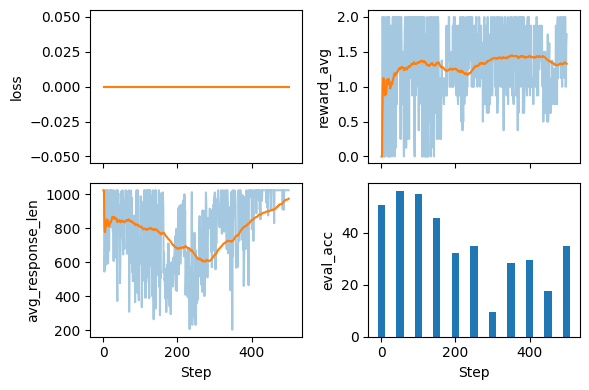

In [47]:
plot_grpo_metrics(
    "7_6_plus_format_reward_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    #save_as="18.pdf"
)

> **关于 `loss` 与 `kl_loss` 的说明**
>
> - 本实验使用 `7_6_plus_format_reward.py` 脚本，采用默认设置 `--kl_coeff 0.0` 和 `--inner_epochs 1`
> - 由于 `--kl_coeff` 设置为 `0.0`，KL 惩罚项被禁用，因此运行过程中记录的 `kl_loss` 始终为 `0`
>
> - 若需启用与第 7.5 节相同设置的 KL 正则化，请运行：
>
> ```bash
> uv run 7_6_plus_format_reward.py \
>     --steps 500 \
>     --max_new_tokens 1024 \
>     --kl_coeff 0.001 \
>     --inner_epochs 2
> ```
>
> - 在默认的 7.6 设置下，记录的 `loss` 同样为 `0`
> - 这是因为运行仅使用一次内部更新（`--inner_epochs 1`），并将模型与同一步骤的自身副本进行比较
> - 因此，策略比率从 `1` 开始，且由于优势值已标准化为均值 `0`，标量策略损失计算结果为 `0`
>
> - 因此在此情况下，`loss = 0` 是默认设置导致的计算产物
> - 也即，它主要反映了运行采用单次内部迭代且无 KL 项，导致记录的标量损失信息量有限
> - 此处更应关注的监测指标包括 `reward_avg`、`format_reward_avg`、`adv_std` 和 `entropy_avg` 等


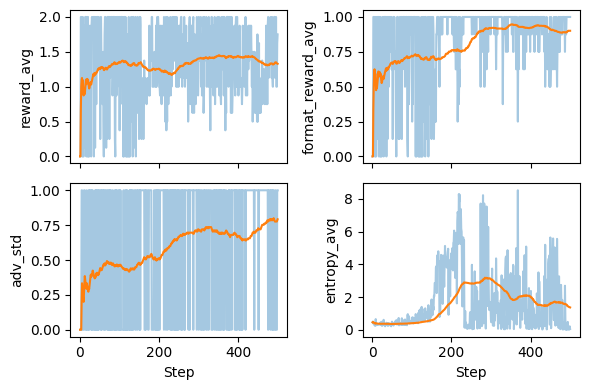

In [48]:
plot_grpo_metrics(
    "7_6_plus_format_reward_metrics.csv",
    columns=["reward_avg", "format_reward_avg", "adv_std", "entropy_avg"],
    #save_as="19.pdf"
)

- 正如我们所见，模型最初有所改善，但在最初的100步之后变得更糟；这可能与模型在这100步之后输出的响应长度缩短有关
- 一种可能的解释是，模型因遵循 `` 标签格式（如上所示）已经获得了过多奖励，而不再足够关注正确性
- 我们可以通过将默认的 `format_reward_weight` 从1.0降低到0.1来减小格式奖励的幅度
- 另一个改进方法是使格式奖励有条件性，即只有在答案正确时才给予奖励（目前，无论答案正确与否都会给予奖励）

```python
if conditional_reward:
    format_reward *= rlvr_reward
reward = rlvr_reward + format_reward_weight * format_reward
```

&nbsp;
## 7.7 更多 GRPO 改进、技巧与实用建议

翻译：

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch07/CH07_F21_raschka.webp?3" width=400>

- 在 DeepSeek-R1 取得成功后的数月里，许多研究者针对原始 GRPO 算法提出了改进方案，这些方案同时提升了算法的稳定性与性能
- 鉴于本章篇幅已较长，本节仅简要列举各项改进/优化措施
- 更多详细信息及代码可通过[补充材料](../03_rlvr_grpo_scripts_advanced/)查阅

1. 零梯度信号过滤（[Yu 等人 2025 年提出的 DAPO](https://arxiv.org/abs/2503.14476)）
2. 主动采样（DAPO）
3. 词元级损失函数（DAPO）
4. 无 KL 散度损失（DAPO 与 [Liu 等人 2025 年提出的 Dr. GRPO](https://arxiv.org/abs/2503.20783)）
5. 更高裁剪阈值（DAPO）
6. 截断重要性采样（[Yao 等人 2025 年](https://fengyao.notion.site/off-policy-rl)）
7. 无标准差归一化（Dr. GRPO）
8. 基于领域特定 KL 强度的 KL 调优；数学领域设为零（[DeepSeek V3.2](https://arxiv.org/abs/2512.02556)）
9. 加权 KL 散度（DeepSeek V3.2）
10. 离策略序列掩码（DeepSeek V3.2）
11. 保留 top-p / top-k 采样掩码（DeepSeek V3.2）
12. 保持原始 GRPO 优势归一化（DeepSeek V3.2）
13. 聚合前按奖励组的组内归一化（[Liu 等人 2026 年提出的 GDPO](https://arxiv.org/abs/2601.05242)）
14. 序列级重要性采样与裁剪（[Zheng 等人 2025 年提出的 GSPO](https://arxiv.org/abs/2507.18071)）
15. 裁剪重要性采样权重而非词元更新（[MiniMax 等人 2025 年提出的 CISPO](https://arxiv.org/abs/2506.13585)）

&nbsp;
## 7.8 总结

- 本节无代码